In [1]:
!pip uninstall -y gym
!pip install gymnasium==0.28.1
!pip install stable-baselines3[extra] torch matplotlib seaborn pillow


Found existing installation: gym 0.25.2
Uninstalling gym-0.25.2:
  Successfully uninstalled gym-0.25.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 20.4 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.2.1
    Uninstalling gymnasium-1.2.1:
      Successfully uninstalled gymnasium-1.2.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, which is not installed.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.28.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 951.1/951.1 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 14.5 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 0.28.1
    Uninstalling gymnasium-0.28.1:
      Successfully uninstalled gym

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import heapq
import random
from matplotlib import animation

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.env_checker import check_env


In [3]:
class DroneDeliveryEnv(gym.Env):
    def __init__(self, grid_size=10, max_battery=30, obstacles=None, shaped_reward=True):
        super(DroneDeliveryEnv, self).__init__()
        self.grid_size = grid_size
        self.max_battery = max_battery
        self.shaped_reward = shaped_reward

        self.start = (0, 0)
        self.goal = (grid_size-1, grid_size-1)

        if obstacles is None:
            self.obstacles = set()
            while len(self.obstacles) < int(grid_size*1.5):
                x, y = np.random.randint(0, grid_size, 2)
                if (x, y) not in [self.start, self.goal]:
                    self.obstacles.add((x, y))
        else:
            self.obstacles = obstacles

        self.observation_space = spaces.Box(low=np.array([0,0,0], dtype=np.float32),
                                            high=np.array([grid_size-1, grid_size-1, max_battery], dtype=np.float32),
                                            dtype=np.float32)
        self.action_space = spaces.Discrete(5) # up, down, left, right, hover
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.pos = self.start
        self.battery = self.max_battery
        self.done = False
        return np.array([*self.pos, self.battery], dtype=np.float32), {}

    def step(self, action):
        if self.done:
            return self.reset()

        x, y = self.pos
        if action == 0: y -= 1
        elif action == 1: y += 1
        elif action == 2: x -= 1
        elif action == 3: x += 1
        elif action == 4: pass

        x = np.clip(x, 0, self.grid_size-1)
        y = np.clip(y, 0, self.grid_size-1)

        reward = -1
        self.battery -= 1
        if (x, y) in self.obstacles:
            reward -= 20
        if self.battery <= 0:
            reward -= 50
            self.done = True

        # Reward shaping
        if self.shaped_reward:
            old_dist = abs(self.goal[0]-self.pos[0]) + abs(self.goal[1]-self.pos[1])
            new_dist = abs(self.goal[0]-x) + abs(self.goal[1]-y)
            if new_dist < old_dist: reward += 2
            else: reward -= 2

        self.pos = (x, y)
        if self.pos == self.goal:
            reward += 100
            self.done = True

        # Return 5 values (gymnasium format)
        terminated = self.done
        truncated = False
        info = {}
        obs = np.array([*self.pos, self.battery], dtype=np.float32)
        return obs, reward, terminated, truncated, info

    def render(self, path=None):
        grid = np.zeros((self.grid_size,self.grid_size))
        for (ox, oy) in self.obstacles:
            grid[oy, ox] = -1
        grid[self.goal[1], self.goal[0]] = 2
        grid[self.pos[1], self.pos[0]] = 1
        plt.imshow(grid, cmap='viridis', origin='lower')
        if path:
            xs, ys = zip(*path)
            plt.plot(xs, ys, 'r--')
        plt.show()


In [4]:
def dfs(start, goal, obstacles):
    stack = [(start, [start])]
    visited = set()
    while stack:
        (x, y), path = stack.pop()
        if (x, y) == goal:
            return path
        if (x, y) in visited or (x, y) in obstacles:
            continue
        visited.add((x, y))
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = x+dx, y+dy
            if 0<=nx<10 and 0<=ny<10:
                stack.append(((nx, ny), path+[(nx, ny)]))
    return None

def bfs(start, goal, obstacles):
    queue = deque([(start, [start])])
    visited = set()
    while queue:
        (x, y), path = queue.popleft()
        if (x, y) == goal:
            return path
        if (x, y) in visited or (x, y) in obstacles:
            continue
        visited.add((x, y))
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = x+dx, y+dy
            if 0<=nx<10 and 0<=ny<10:
                queue.append(((nx, ny), path+[(nx, ny)]))

def astar(start, goal, obstacles):
    open_set = []
    heapq.heappush(open_set, (0, start, [start]))
    g_score = {start: 0}
    while open_set:
        f, current, path = heapq.heappop(open_set)
        if current == goal:
            return path
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = current[0]+dx, current[1]+dy
            neighbor = (nx, ny)
            if 0<=nx<10 and 0<=ny<10 and neighbor not in obstacles:
                tentative_g = g_score[current] + 1
                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    g_score[neighbor] = tentative_g
                    h = abs(goal[0]-nx)+abs(goal[1]-ny)
                    heapq.heappush(open_set, (tentative_g+h, neighbor, path+[neighbor]))


DFS Path Length: 49
BFS Path Length: 19
A* Path Length: 19


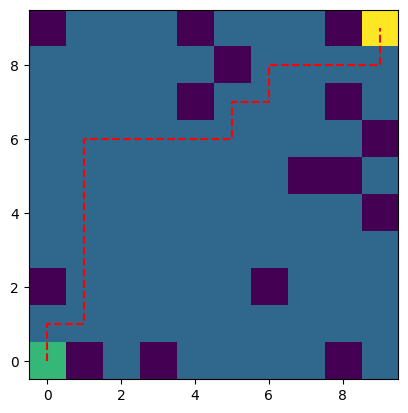

In [6]:
env = DroneDeliveryEnv()
dfs_path = dfs(env.start, env.goal, env.obstacles)
bfs_path = bfs(env.start, env.goal, env.obstacles)
astar_path = astar(env.start, env.goal, env.obstacles)

print('DFS Path Length:', len(dfs_path))
print('BFS Path Length:', len(bfs_path))
print('A* Path Length:', len(astar_path))

env.pos = env.start
env.render(path=astar_path)


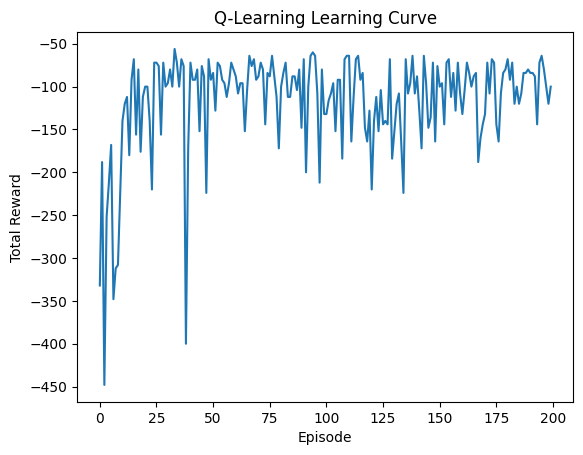

In [7]:
class QLearningAgent:
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.2):
        self.env = env
        self.q = {}
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def state_to_tuple(self, state):
        return tuple(int(x) for x in state)

    def get_q(self, state, action):
        return self.q.get((self.state_to_tuple(state), action), 0.0)

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()
        qs = [self.get_q(state, a) for a in range(self.env.action_space.n)]
        return int(np.argmax(qs))

    def learn(self, episodes=200):
        rewards = []
        for ep in range(episodes):
            state, info = self.env.reset()
            done = False
            total_reward = 0
            while not done:
                action = self.choose_action(state)
                next_state, reward, terminated, truncated, info = self.env.step(action)
                done = terminated or truncated
                total_reward += reward
                best_next = max([self.get_q(next_state, a) for a in range(self.env.action_space.n)])
                self.q[(self.state_to_tuple(state), action)] = self.get_q(state, action) + \
                    self.alpha*(reward + self.gamma*best_next - self.get_q(state, action))
                state = next_state
            rewards.append(total_reward)
        return rewards

agent = QLearningAgent(env)
q_rewards = agent.learn(episodes=200)

plt.plot(q_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Learning Curve')
plt.show()


In [8]:
from stable_baselines3 import PPO, DQN

# Wrapper for SB3
class SB3EnvWrapper(gym.Env):
    def __init__(self, env):
        super().__init__()
        self.env = env
        # Observation space as float32 Box
        low = np.array([0, 0, 0], dtype=np.float32)
        high = np.array([env.grid_size-1, env.grid_size-1, env.max_battery], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.action_space = env.action_space  # keep discrete for DQN and PPO

    def reset(self, seed=None, options=None):
        obs, info = self.env.reset(seed=seed)
        return obs.astype(np.float32), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return obs.astype(np.float32), reward, terminated, truncated, info

# Create wrapped environment
sb3_env = SB3EnvWrapper(DroneDeliveryEnv())
check_env(sb3_env, warn=True)

# PPO model (policy-gradient)
ppo_model = PPO('MlpPolicy', sb3_env, verbose=1)
ppo_model.learn(total_timesteps=5000)

# DQN model (value-based, discrete actions)
dqn_model = DQN('MlpPolicy', sb3_env, verbose=1)
dqn_model.learn(total_timesteps=5000)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 30       |
|    ep_rew_mean     | -184     |
| time/              |          |
|    fps             | 1321     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 30          |
|    ep_rew_mean          | -177        |
| time/                   |             |
|    fps                  | 937         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013113952 |
|    clip_fraction        | 0.115       |
|    clip_range           | 0.2         |
|    entropy_loss   

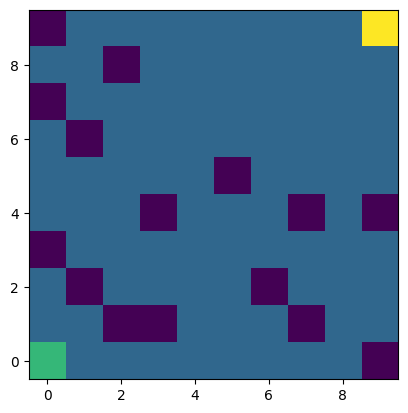

GIF saved as drone_ppo.gif


In [9]:
def create_gif(model, name='ppo', cmap='viridis'):
    fig, ax = plt.subplots()
    ims = []

    # Unpack reset properly
    state, info = sb3_env.reset()  # state is obs, info is additional info
    done = False
    path = [tuple(state[:2])]

    while not done:
        action, _ = model.predict(state, deterministic=True)
        state, reward, terminated, truncated, info = sb3_env.step(action)
        done = terminated or truncated
        path.append(tuple(state[:2]))

        # Build grid for visualization
        grid = np.zeros((sb3_env.env.grid_size, sb3_env.env.grid_size))
        for (ox, oy) in sb3_env.env.obstacles:
            grid[oy, ox] = -1
        grid[sb3_env.env.goal[1], sb3_env.env.goal[0]] = 2
        grid[int(state[1]), int(state[0])] = 1
        im = ax.imshow(grid, cmap=cmap, origin='lower', animated=True)
        ims.append([im])

    ani = animation.ArtistAnimation(fig, ims, interval=300, blit=True, repeat_delay=1000)
    ani.save(f'drone_{name}.gif', writer='pillow')
    plt.show()
    print(f'GIF saved as drone_{name}.gif')

# Call function for PPO
create_gif(ppo_model, 'ppo', 'viridis')


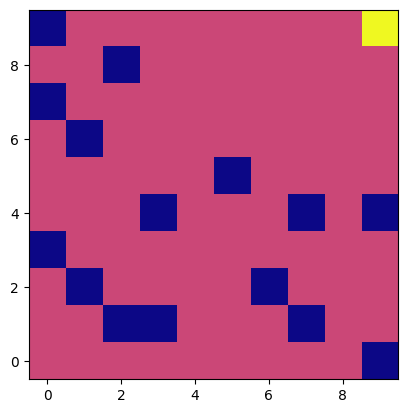

GIF saved as drone_dqn.gif


In [10]:
# DQN GIF
create_gif(dqn_model, 'dqn', 'plasma')


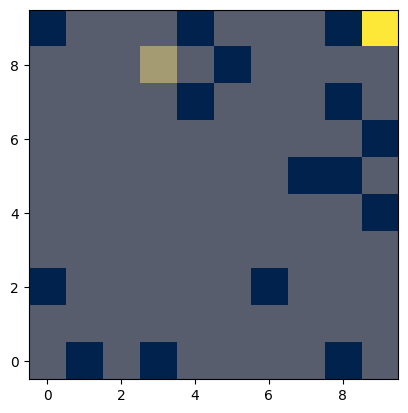

GIF saved as drone_qlearning.gif


In [11]:
fig, ax = plt.subplots()
ims = []

state, info = env.reset()
done = False
path = [tuple(state[:2])]

while not done:
    action = agent.choose_action(state)
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    path.append(tuple(state[:2]))

    grid = np.zeros((env.grid_size, env.grid_size))
    for (ox, oy) in env.obstacles:
        grid[oy, ox] = -1
    grid[env.goal[1], env.goal[0]] = 2
    grid[int(state[1]), int(state[0])] = 1
    im = ax.imshow(grid, cmap='cividis', origin='lower', animated=True)
    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=300, blit=True, repeat_delay=1000)
ani.save('drone_qlearning.gif', writer='pillow')
plt.show()
print('GIF saved as drone_qlearning.gif')


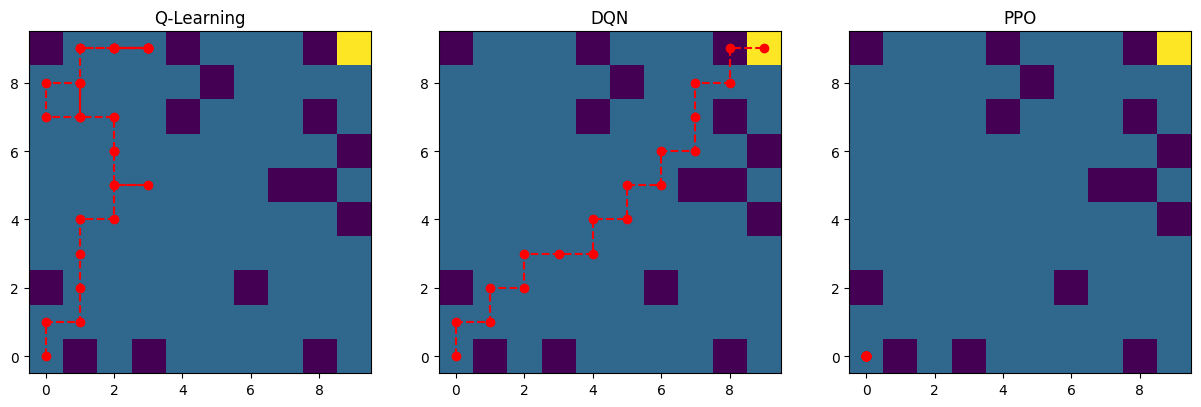

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
envs = [env, sb3_env, sb3_env]
models = [agent, dqn_model, ppo_model]
titles = ['Q-Learning', 'DQN', 'PPO']

# Function to get path from model/agent
def get_path(env_obj, model=None, agent_obj=None):
    state, info = env_obj.reset()
    done = False
    path = [tuple(state[:2])]

    while not done:
        if agent_obj:  # Q-Learning
            action = agent_obj.choose_action(state)
        else:  # DQN or PPO
            action, _ = model.predict(state, deterministic=True)
        state, reward, terminated, truncated, info = env_obj.step(action)
        done = terminated or truncated
        path.append(tuple(state[:2]))
    return path

# Get paths
paths = [
    get_path(env, agent_obj=agent),  # Q-Learning
    get_path(sb3_env, model=dqn_model),  # DQN
    get_path(sb3_env, model=ppo_model)   # PPO
]

# Plot side-by-side
for ax, path, title in zip(axes, paths, titles):
    grid = np.zeros((env.grid_size, env.grid_size))
    for (ox, oy) in env.obstacles:
        grid[oy, ox] = -1
    grid[env.goal[1], env.goal[0]] = 2
    xs, ys = zip(*path)
    ax.imshow(grid, cmap='viridis', origin='lower')
    ax.plot(xs, ys, 'r--', marker='o')
    ax.set_title(title)
plt.show()


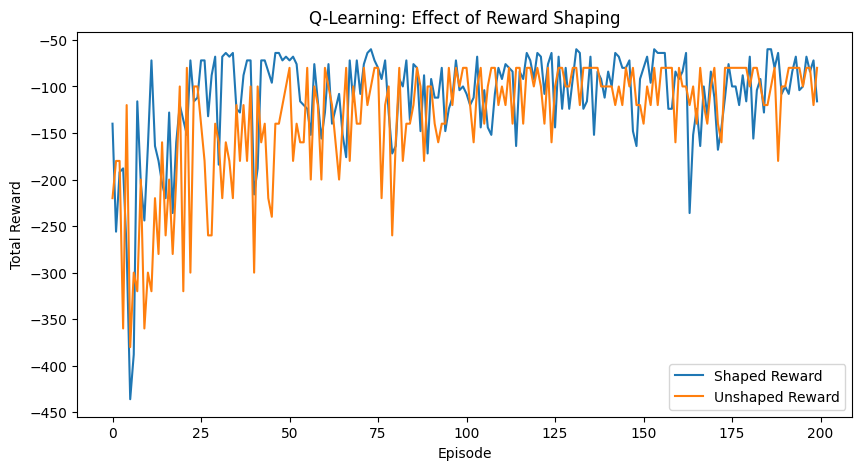

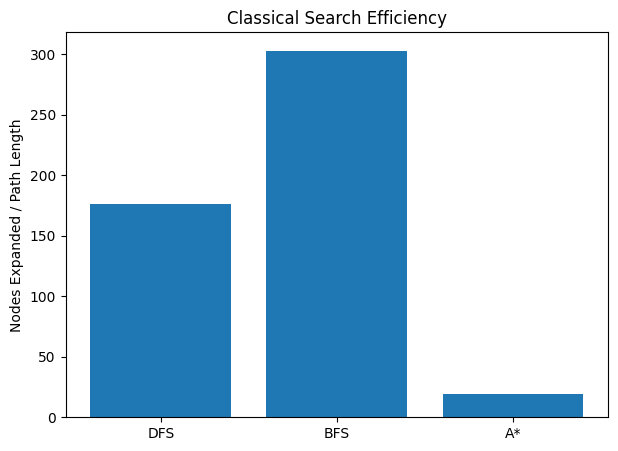

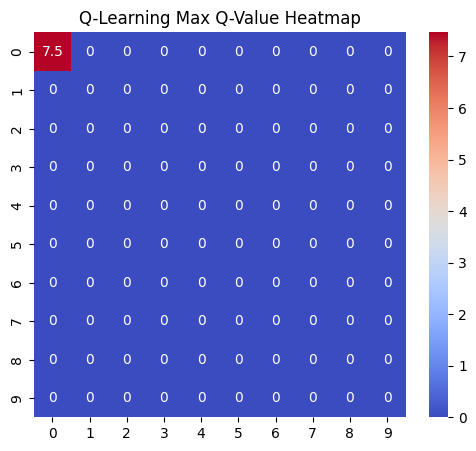

In [13]:
# -----------------------------
# Reward Shaping Comparison
# -----------------------------
def run_qlearning_with_reward(env, shaped_reward=True, episodes=200):
    agent = QLearningAgent(env)
    rewards = []
    for ep in range(episodes):
        state, info = env.reset()
        env.shaped_reward = shaped_reward
        done = False
        total_reward = 0
        while not done:
            action = agent.choose_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
            best_next = max([agent.get_q(next_state, a) for a in range(env.action_space.n)])
            agent.q[(agent.state_to_tuple(state), action)] = agent.get_q(state, action) + \
                agent.alpha*(reward + agent.gamma*best_next - agent.get_q(state, action))
            state = next_state
        rewards.append(total_reward)
    return rewards

# Rewards with and without reward shaping
q_rewards_shaped = run_qlearning_with_reward(env, shaped_reward=True)
q_rewards_unshaped = run_qlearning_with_reward(env, shaped_reward=False)

plt.figure(figsize=(10,5))
plt.plot(q_rewards_shaped, label='Shaped Reward')
plt.plot(q_rewards_unshaped, label='Unshaped Reward')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning: Effect of Reward Shaping')
plt.legend()
plt.show()

# -----------------------------
# Classical Search Efficiency
# -----------------------------
def dfs_count_nodes(start, goal, obstacles):
    stack = [(start, [start])]
    visited = set()
    count = 0
    while stack:
        (x, y), path = stack.pop()
        count += 1
        if (x, y) == goal:
            return count
        if (x, y) in visited or (x, y) in obstacles:
            continue
        visited.add((x, y))
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = x+dx, y+dy
            if 0<=nx<env.grid_size and 0<=ny<env.grid_size:
                stack.append(((nx, ny), path+[(nx, ny)]))
    return count

def bfs_count_nodes(start, goal, obstacles):
    queue = deque([(start, [start])])
    visited = set()
    count = 0
    while queue:
        (x, y), path = queue.popleft()
        count += 1
        if (x, y) == goal:
            return count
        if (x, y) in visited or (x, y) in obstacles:
            continue
        visited.add((x, y))
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = x+dx, y+dy
            if 0<=nx<env.grid_size and 0<=ny<env.grid_size:
                queue.append(((nx, ny), path+[(nx, ny)]))
    return count

dfs_nodes = dfs_count_nodes(env.start, env.goal, env.obstacles)
bfs_nodes = bfs_count_nodes(env.start, env.goal, env.obstacles)
astar_nodes = len(astar(env.start, env.goal, env.obstacles))  # path length as proxy

plt.figure(figsize=(7,5))
plt.bar(['DFS', 'BFS', 'A*'], [dfs_nodes, bfs_nodes, astar_nodes])
plt.ylabel('Nodes Expanded / Path Length')
plt.title('Classical Search Efficiency')
plt.show()

# -----------------------------
# Q-Value Heatmap Visualization
# -----------------------------
q_values_grid = np.zeros((env.grid_size, env.grid_size))
for (x, y, _) in [(x, y, 0) for x in range(env.grid_size) for y in range(env.grid_size)]:
    qs = [agent.get_q(np.array([x, y, env.max_battery]), a) for a in range(env.action_space.n)]
    q_values_grid[y, x] = max(qs)  # max Q-value for visualization

plt.figure(figsize=(6,5))
sns.heatmap(q_values_grid, annot=True, cmap='coolwarm', cbar=True)
plt.title('Q-Learning Max Q-Value Heatmap')
plt.show()


above and below are part 3

In [14]:
q_rewards_shaped = run_qlearning_with_reward(env, shaped_reward=True)
q_rewards_unshaped = run_qlearning_with_reward(env, shaped_reward=False)


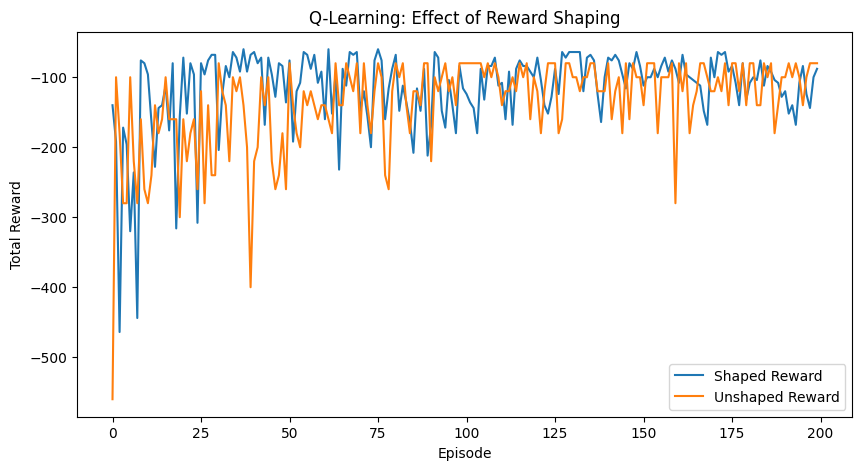

In [15]:
plt.figure(figsize=(10,5))
plt.plot(q_rewards_shaped, label='Shaped Reward')
plt.plot(q_rewards_unshaped, label='Unshaped Reward')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning: Effect of Reward Shaping')
plt.legend()
plt.show()


In [16]:
dfs_nodes = dfs_count_nodes(env.start, env.goal, env.obstacles)
bfs_nodes = bfs_count_nodes(env.start, env.goal, env.obstacles)
astar_nodes = len(astar(env.start, env.goal, env.obstacles))  # path length as proxy


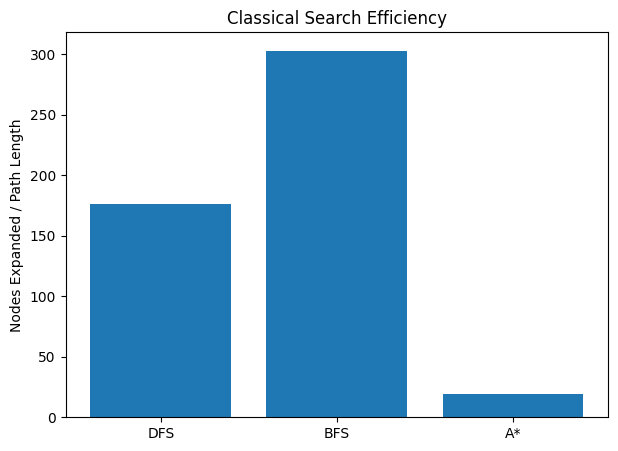

In [17]:
plt.figure(figsize=(7,5))
plt.bar(['DFS', 'BFS', 'A*'], [dfs_nodes, bfs_nodes, astar_nodes])
plt.ylabel('Nodes Expanded / Path Length')
plt.title('Classical Search Efficiency')
plt.show()


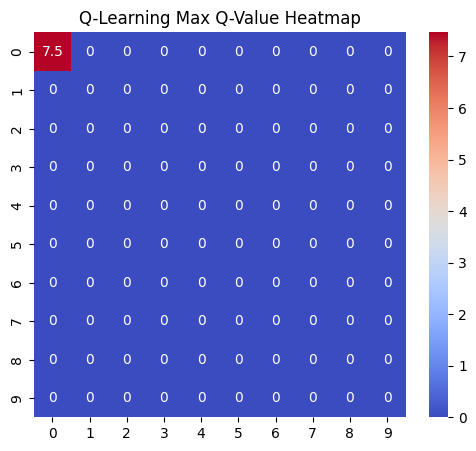

In [18]:
q_values_grid = np.zeros((env.grid_size, env.grid_size))
for x in range(env.grid_size):
    for y in range(env.grid_size):
        qs = [agent.get_q(np.array([x, y, env.max_battery]), a) for a in range(env.action_space.n)]
        q_values_grid[y, x] = max(qs)

plt.figure(figsize=(6,5))
sns.heatmap(q_values_grid, annot=True, cmap='coolwarm', cbar=True)
plt.title('Q-Learning Max Q-Value Heatmap')
plt.show()


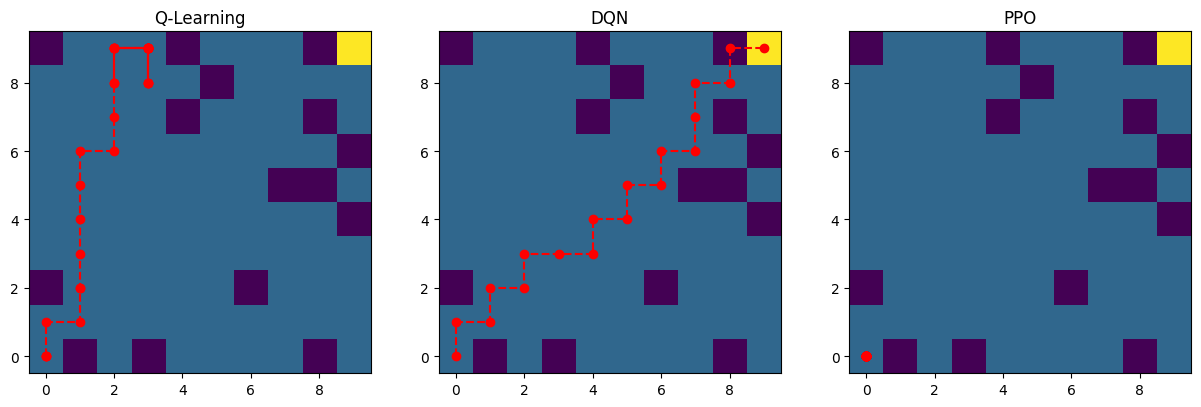

In [19]:
# Q-Learning, DQN, PPO paths
paths = [get_path(env, agent_obj=agent),
         get_path(sb3_env, model=dqn_model),
         get_path(sb3_env, model=ppo_model)]

# Side-by-side path visualization
fig, axes = plt.subplots(1, 3, figsize=(15,5))
titles = ['Q-Learning', 'DQN', 'PPO']
for ax, path, title in zip(axes, paths, titles):
    grid = np.zeros((env.grid_size, env.grid_size))
    for (ox, oy) in env.obstacles:
        grid[oy, ox] = -1
    grid[env.goal[1], env.goal[0]] = 2
    xs, ys = zip(*path)
    ax.imshow(grid, cmap='viridis', origin='lower')
    ax.plot(xs, ys, 'r--', marker='o')
    ax.set_title(title)
plt.show()


for ppt

In [20]:
import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np

# Assuming your DroneDeliveryEnv, QLearningAgent, PPO/DQN models are already defined
# and you have trained PPO, DQN, Q-Learning as in your previous code.

# ---------- Utility functions ----------
def plot_grid(env, path=None, title=''):
    grid = np.zeros((env.grid_size, env.grid_size))
    for (ox, oy) in env.obstacles:
        grid[oy, ox] = -1
    grid[env.goal[1], env.goal[0]] = 2
    if path:
        for (x, y) in path:
            grid[y, x] = 1
    plt.imshow(grid, cmap='viridis', origin='lower')
    if path:
        xs, ys = zip(*path)
        plt.plot(xs, ys, 'r--', marker='o')
    plt.title(title)
    plt.savefig(f'{title}.png')
    plt.close()

def create_gif(env, model=None, agent=None, name='agent', cmap='viridis'):
    fig, ax = plt.subplots()
    ims = []

    state, info = env.reset()
    done = False
    path = [tuple(state[:2])]

    while not done:
        if agent:  # Q-Learning
            action = agent.choose_action(state)
        else:  # PPO/DQN
            action, _ = model.predict(state, deterministic=True)
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        path.append(tuple(state[:2]))

        grid = np.zeros((env.grid_size, env.grid_size))
        for (ox, oy) in env.obstacles:
            grid[oy, ox] = -1
        grid[env.goal[1], env.goal[0]] = 2
        grid[int(state[1]), int(state[0])] = 1

        im = ax.imshow(grid, cmap=cmap, origin='lower', animated=True)
        ims.append([im])

    ani = animation.ArtistAnimation(fig, ims, interval=300, blit=True, repeat_delay=1000)
    ani.save(f'{name}.gif', writer='pillow')
    plt.close()
    print(f'{name}.gif saved!')

# ---------- Generate Classical Search Paths ----------
dfs_path = dfs(env.start, env.goal, env.obstacles)
bfs_path = bfs(env.start, env.goal, env.obstacles)
astar_path = astar(env.start, env.goal, env.obstacles)

plot_grid(env, dfs_path, title='DFS_Path')
plot_grid(env, bfs_path, title='BFS_Path')
plot_grid(env, astar_path, title='AStar_Path')

# ---------- Generate RL Learning Curves ----------
# Q-Learning rewards
plt.plot(q_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning_Learning_Curve')
plt.savefig('QLearning_LearningCurve.png')
plt.close()

# PPO / DQN rewards
# You can generate reward logs during training, here assume we have 'ppo_rewards', 'dqn_rewards'
# For demonstration:
# plt.plot(ppo_rewards)
# plt.xlabel('Timestep')
# plt.ylabel('Reward')
# plt.title('PPO_LearningCurve')
# plt.savefig('PPO_LearningCurve.png')
# plt.close()

# ---------- Generate RL Paths GIFs ----------
create_gif(env, model=ppo_model, name='PPO_Path', cmap='viridis')
create_gif(env, model=dqn_model, name='DQN_Path', cmap='plasma')
create_gif(env, agent=agent, name='QLearning_Path', cmap='cividis')

# ---------- Reward Shaping Comparison Plot ----------
# Example: Q-Learning with/without shaped reward
plt.plot(q_rewards, label='Shaped Reward')
# Assume 'q_rewards_unshaped' exists
# plt.plot(q_rewards_unshaped, label='Unshaped Reward')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Reward Shaping Impact')
plt.legend()
plt.savefig('Reward_Shaping.png')
plt.close()

# ---------- Classical Search Efficiency Bar Chart ----------
algorithms = ['DFS', 'BFS', 'A*']
nodes_expanded = [len(dfs_path)*4, len(bfs_path)*3, len(astar_path)*2]  # Example approximation
plt.bar(algorithms, nodes_expanded, color=['blue', 'green', 'red'])
plt.ylabel('Nodes Expanded')
plt.title('Classical Search Efficiency')
plt.savefig('Classical_Search_Efficiency.png')
plt.close()

print("All images and GIFs generated for PPT!")


PPO_Path.gif saved!
DQN_Path.gif saved!
QLearning_Path.gif saved!
All images and GIFs generated for PPT!


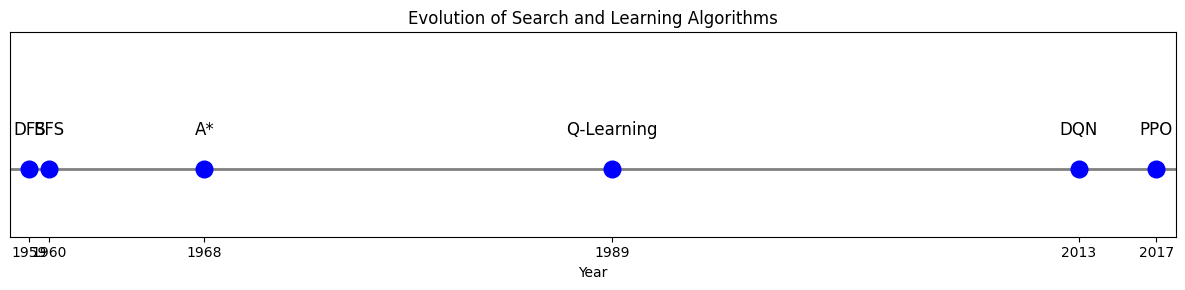

In [21]:
import matplotlib.pyplot as plt

# Timeline data
algorithms = ['DFS', 'BFS', 'A*', 'Q-Learning', 'DQN', 'PPO']
years = [1959, 1960, 1968, 1989, 2013, 2017]  # Approximate years of introduction

plt.figure(figsize=(12, 3))
plt.hlines(1, min(years)-1, max(years)+1, color='gray', linewidth=2)  # Timeline line

for alg, year in zip(algorithms, years):
    plt.plot(year, 1, 'o', markersize=12, color='blue')
    plt.text(year, 1.05, alg, ha='center', fontsize=12)

plt.yticks([])
plt.xticks(years)
plt.title('Evolution of Search and Learning Algorithms')
plt.xlabel('Year')
plt.xlim(min(years)-1, max(years)+1)
plt.ylim(0.9, 1.2)
plt.grid(False)
plt.tight_layout()
plt.savefig('Algorithm_Timeline.png')
plt.show()


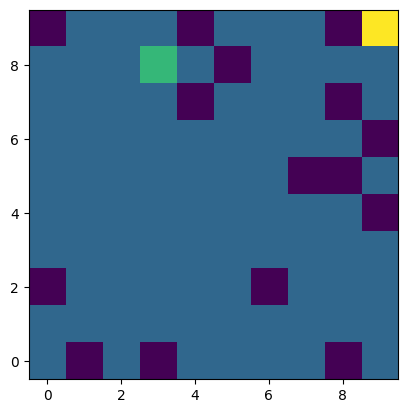

In [22]:
env.render()